# Foundations of Machine learning

Problem Set 1

Emily Fu

In [1]:
# importing packages and methods

import numpy as np
import pandas as pd

# plotting 
import matplotlib.pyplot as plt

In [ ]:
# setting parameters

# possible dimensions of theta
dim_thetas = [2, 3, 10]

# number of draws
nreps = 10000

# vary the values of r
r_grid = np.linspace(0, 6, 61)

# function to calculate loss 1/k ||theta - thetahat||^2 in each draw
def loss_per_draw(theta, thetahat):

    # pivot to calculate loss per draw
    theta = np.asarray(theta).reshape(1, -1)

    # dimension of theta
    k = theta.shape[1]

    # return loss per draw
    return(np.sum((thetahat - theta) ** 2, axis=1) / k)


What I'm seeing:



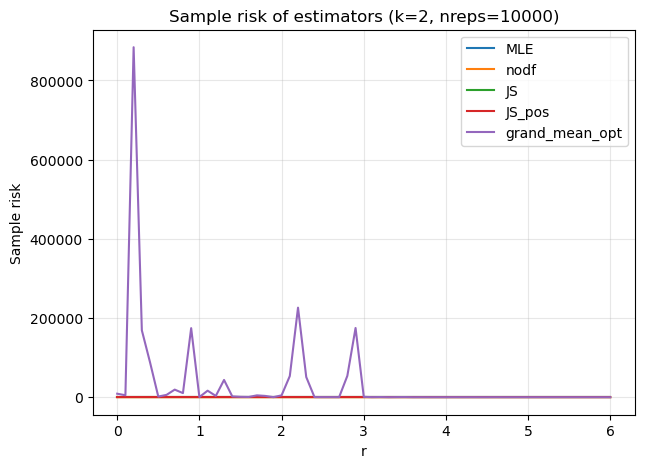

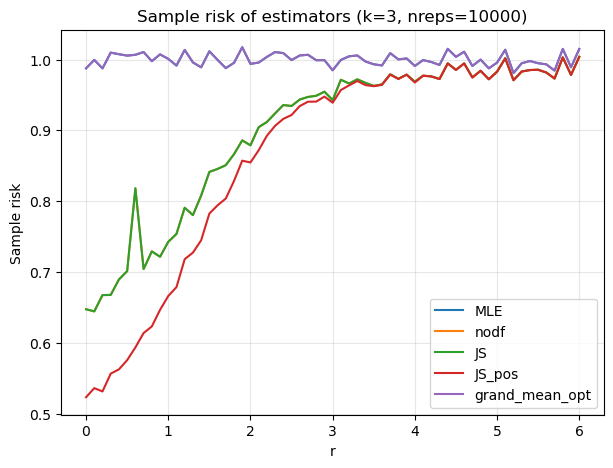

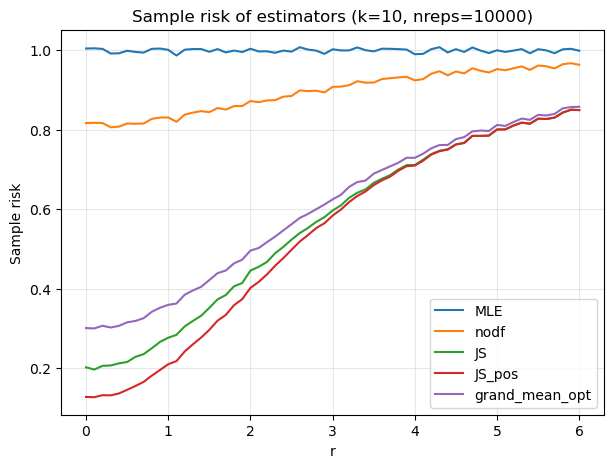

In [ ]:
# container to store risk curves
risks = {}

for k in dim_thetas:
    # print(k)

    # 1. Pick a random vector theta_1 of length 1 
    # (you can pick random normally distributed components and then normalize),
    theta_1 = np.random.normal(size=k)
    theta_1 = theta_1 / np.linalg.norm(theta_1)

    risks[k] = {'MLE': np.zeros(len(r_grid)),
                'nodf': np.zeros(len(r_grid)),
                'JS': np.zeros(len(r_grid)),
                'JS_pos': np.zeros(len(r_grid)),
                'grand_mean_opt': np.zeros(len(r_grid))}

    for i, r in enumerate(r_grid):

        # 2. take θ = r*theta_1 for r in [0, 6],
        theta = r * theta_1

        # print(f'Dimension: {k}, r: {r}')

        # 3. repeatedly (say, 10,000 times) draw X ∼ N(theta, I),
        X = np.random.multivariate_normal(mean=theta, cov=np.eye(k), size=nreps)

        # mean of Xs, squared Xs, and variance
        X2_bar = np.sum(X**2, axis=1, keepdims=True)
        Xbar = np.mean(X, axis=1, keepdims=True)
        s2_X = np.mean((X - Xbar)**2, axis=1, keepdims=True)

        # calculate estimates theta_hat

        # 1. the MLE
        thetahat_MLE = X

        # 2. the estimator (1 - 1/X2_bar)*X
        # i think this is the no degrees of freedom thing
        shrink_nodf = 1 - (1 / (X2_bar))
        thetahat_nodf = shrink_nodf * X

        # 3. the James-Stein estimator
        shrink_js = 1 - ((k - 2) / (X2_bar))
        thetahat_js = shrink_js * X

        # 4. the positive part James-Stein estimator,
        # take zero whenever shrinkage factor is negative
        shrink_js_pos = np.maximum(0, shrink_js)
        thetahat_js_pos = shrink_js_pos * X

        # 5. the estimator shrinking to the grand mean using the 
        # optimal shrinkage factor 1 - ((k - 3) / k) / s2_X
        shrink_grand = 1 - (((k - 3) / k) / (s2_X))
        thetahat_optimal = Xbar + shrink_grand * (X - Xbar)

        # evaluating average loss across all simulation draws for each estimator
        risks[k]['MLE'][i] = np.mean(loss_per_draw(theta, thetahat_MLE))
        risks[k]['nodf'][i] = np.mean(loss_per_draw(theta, thetahat_nodf))
        risks[k]['JS'][i] = np.mean(loss_per_draw(theta, thetahat_js))
        risks[k]['JS_pos'][i] = np.mean(loss_per_draw(theta, thetahat_js_pos))
        risks[k]['grand_mean_opt'][i] = np.mean(loss_per_draw(theta, thetahat_optimal))

    # For a given dimension, plot the risk functions of all these estimators in one figure.
    plt.figure(figsize=(7, 5))
    for name, curve in risks[k].items():
        plt.plot(r_grid, curve, label=name)
    plt.title(f'Sample risk of estimators (k={k}, nreps={nreps})')
    plt.xlabel('r')
    plt.ylabel('Sample risk')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
